# LimnoTech Rating Curves: Getting Started

A rating curve converts a stage measurement into a discharge. Stage is measured
continuously; discharge is measured by a field crew, at high cost. The rating is what
turns a continuous stage record into a continuous discharge record.

Contents:

1. [Fitting one rating](#one), on synthetic data with a known answer
2. [A real station: USGS 06893578](#station)
3. [Comparing model families](#compare)
4. [Saving a fit and reading it back](#exports)

Everything past that has a notebook of its own:

- `psis.ipynb`: `elpd_loo` and Pareto-k, the predictive score models are ranked on
- `extras.ipynb`: stage datums, the stage of zero flow, sampler diagnostics,
  cross-validation, the export files in depth, the MAGL file route, the map, and fitting
  many sites at once
- `pagaia.ipynb`: the same workflow on a LimnoTech MAGL station (SBR-09)
- `usgs_06893578.ipynb`: one station's whole record, taken apart

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import limnotech_rating_curves as lrc

print("limnotech_rating_curves", lrc.__version__)
print("default sampler:", lrc.settings.NUTS_SAMPLER)
print("default models:", lrc.models.catalog.DEFAULT_KEYS)

limnotech_rating_curves 1.1.0
default sampler: nutpie
default models: ('power_law', 'power_law_2seg', 'spline', 'bdrc_gplm0', 'linear', 'quadratic', 'exponential')


In [2]:
lrc.models.catalog.all_keys()

['power_law',
 'power_law_2seg',
 'power_law_3seg',
 'spline',
 'bdrc_gplm0',
 'bdrc_gplm',
 'bdrc_plm0',
 'bdrc_plm',
 'linear',
 'quadratic',
 'exponential']

<a id="one"></a>
## 1. Fitting one rating

The input is paired stage and discharge measurements: a DataFrame with a stage column and a discharge column, two arrays, or one of the loaders shown later.

The points are drawn from $Q = 12\,(h - 1.5)^{2.1}$ with multiplicative noise, a power law whose stage of zero flow is exactly 1.5 ft - so the fit has the same shape as the model, evenly spaced measurements, and no datum problem. Real data has none of those properties, which is why everything from section 2 on uses a real sensor.

In [3]:
rng = np.random.default_rng(0)
stage = np.linspace(2.0, 7.0, 16)
true_zero_flow = 1.5
measurements = pd.DataFrame({
    "stage_ft": stage,
    "discharge_cfs": 12.0 * (stage - true_zero_flow) ** 2.1
                     * np.exp(rng.normal(0, 0.25, stage.size)),
})
measurements.head()

,stage_ft,discharge_cfs
0,2.000000,2.888479
1,2.333333,7.916943
2,2.666667,19.467156
3,3.000000,28.864383
4,3.333333,37.482513


In [4]:
rating = lrc.fit_rating(measurements)          # power law, full MCMC, seeded

print("discharge at 5 ft:", round(rating.predict(5.0), 2), "cfs")
lower, upper = rating.interval(5.0)
print("95% credible interval:", round(lower, 2), "to", round(upper, 2), "cfs")
print(rating.metrics)

c:\Users\dfarmer\AppData\Local\miniconda3\envs\rating_curves\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Output()

Output()

Output()

Output()

Output()

discharge at 5 ft: 152.19 cfs


95% credible interval: 94.7 to 231.14 cfs
Metrics(n=16, nse=0.923, rmse=30.1, r2_log=0.980, elpd_loo=nan)


`predict` returns the posterior mean and `interval` returns the credible interval around
it. Every model in this package provides both.

`curve()` returns the fitted rating as a table, and `plot()` draws it.

In [5]:
rating.curve().head(3)

Output()

,stage_ft,discharge_cfs,discharge_median_cfs,lower,upper
0,1.500000,0.017511,0.0,NaN,NaN
1,1.530151,0.028380,0.0,NaN,NaN
2,1.560302,0.045705,0.0,NaN,NaN


Output()

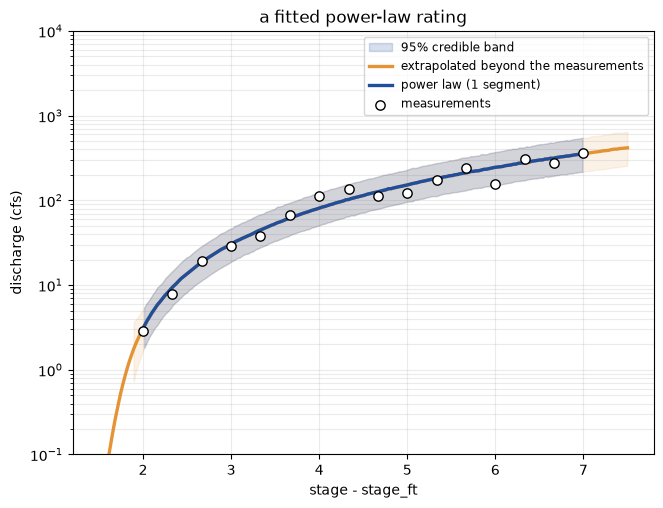

In [6]:
ax = rating.plot()
ax.set_title("a fitted power-law rating");

Output()

fitted stage of zero flow: 1.592 ft (the data was drawn with 1.5)


Output()

array([<Axes: title={'center': 'a power law is a line in log-log space'}, xlabel='effective head, stage - 1.59195 ft (ft)', ylabel='discharge (cfs)'>,
       <Axes: title={'center': 'residuals as a ratio, across the stage range'}, xlabel='stage - stage_ft', ylabel='predicted / observed'>],
      dtype=object)

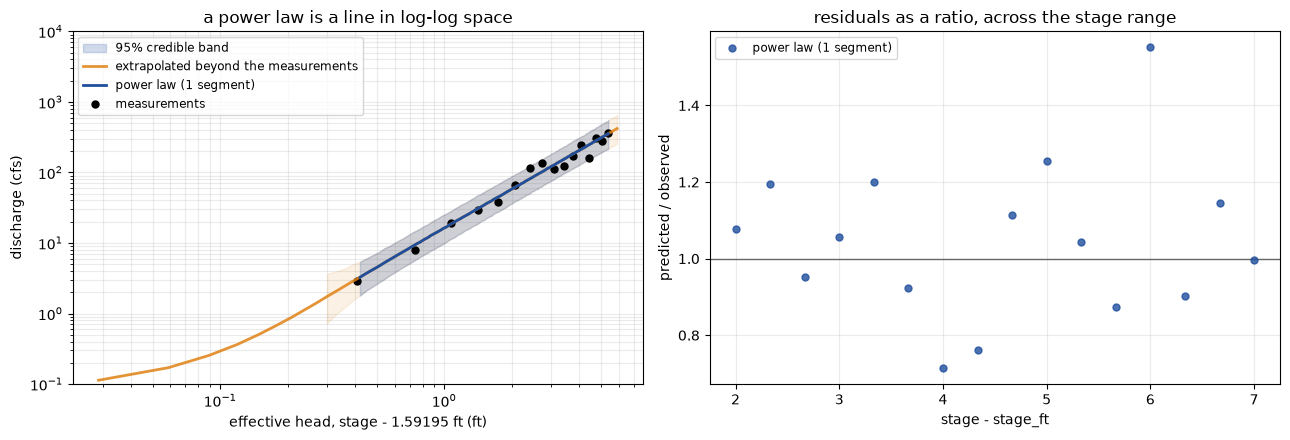

In [7]:
# The two panels a rating is judged on: the shape in log-log space, where a power law is
# a straight line, and the residuals as a ratio, which says whether the error is the same
# size at low flow as at high.
print(f"fitted stage of zero flow: {rating.zero_flow:.3f} ft "
      f"(the data was drawn with {true_zero_flow})")
rating.plot_check()

### The fitted curve, written out

A power law is three numbers, which is the reason to prefer it when a rating has to be
explained to somebody: a coefficient, an exponent, and the stage of zero flow.
`equation()` writes them out and `coefficients` returns them - a form that can be quoted
in a memo, checked by hand, and typed into a spreadsheet that has never heard of PyMC.

Do not expect the three fitted numbers to match the three the data was drawn from. $C$,
$\beta$ and $e$ trade off against each other: a stage of zero flow fitted a little high
is absorbed by a lower exponent and a larger coefficient, tracing nearly the same curve.
Judge the curve, not the coefficients.

In [8]:
print("fitted:     ", rating.equation())
print("drawn from:  Q = 12 (h - 1.5)^2.1")
rating.coefficients

fitted:      Q = 15.7617 (h - 1.59195)^1.82926
drawn from:  Q = 12 (h - 1.5)^2.1


{'coefficient': 15.761700229365209,
 'exponents': array([1.82925753]),
 'breakpoints': array([1.59194799])}

### Other input shapes

In [9]:
# a DataFrame whose columns are named something else
odd = measurements.rename(columns={"stage_ft": "WSE (ft)", "discharge_cfs": "Q"})
lrc.fit_rating(odd, stage="WSE (ft)", discharge="Q").metrics.r2_log

c:\Users\dfarmer\AppData\Local\miniconda3\envs\rating_curves\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Output()

Output()

Output()

0.9796161453518268

In [10]:
# two arrays
lrc.fit_rating(measurements["stage_ft"].to_numpy(),
               measurements["discharge_cfs"].to_numpy()).metrics.r2_log

c:\Users\dfarmer\AppData\Local\miniconda3\envs\rating_curves\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Output()

Output()

Output()

0.9798620811755074

<a id="station"></a>
## 2. The station this notebook runs on: USGS 06893578

**Blue River at Stadium Drive, Kansas City, MO** -
[the site page](https://waterdata.usgs.gov/monitoring-location/USGS-06893578/).

A gage provides three things, and they are not interchangeable:

- **Field measurements**: real gauged (stage, discharge) pairs, a crew in the water with
  a meter. This is the observed sample, and the only thing here worth fitting to.
- **The published rating**: the curve the USGS maintains, shift-corrected by hand. It is
  a fitted product rather than data, so it is a reference to compare against, never
  something to fit to. The approved 15-minute discharge record was computed *through*
  it, so a stage and a discharge from that record are one measurement and its rating
  lookup, not two measurements.
- **The gage datum**: `alt_va`, the elevation of gage height zero, and the vertical datum
  it is on.

Requires network access to USGS Water Data, and nothing else.

In [11]:
from limnotech_rating_curves.data import usgs

SITE = "06893578"          # gage numbers are strings; a leading zero is significant
usgs.site_info(SITE).T

,06893578
station_name,"Blue River at Stadium Drive in Kansas City, MO"
latitude,39.058338
longitude,-94.511898
alt_va,718.41
alt_datum_cd,NAVD88
alt_acy_va,0.02
drainage_area_sqmi,256.0


### Selecting a time window

There are 246 field measurements here going back to 2002, too long a record to fit one
curve to: the channel was reworked and the rating rebuilt several times over those years,
which `usgs_06893578.ipynb` takes apart. So the sample is a recent window.

The timestamps come back tz-aware in UTC. Strip the timezone before filtering or
plotting: comparing a tz-aware column against a naive `pd.Timestamp` raises, and a
tz-aware matplotlib axis is labelled with UTC offsets.

In [ ]:
field = usgs.measurements(SITE)          # the independent observations
field_local = field.assign(time=field["time"].dt.tz_localize(None))
recent_local = field_local[field_local["time"] >= pd.Timestamp("2024-01-01")]

print("all measurements:", len(field), "|",
      field_local["time"].min().date(), "to", field_local["time"].max().date())
print("since 2024-01-01:", len(recent_local))
recent_local.head()

### The record and the measurements, plotted

Two views of the same window. On the left, stage against discharge: the approved
15-minute record as a cloud with the field measurements on top of it - the plane a rating
lives in. On the right, the same discharge against time, which says whether the
measurements were taken across the range of events or all in one season.

`lrc.view.plots.plot_rating_cloud` draws the left panel with the published rating over
it; `usgs_06893578.ipynb` uses it.

15:08:21 INFO    limnotech_rating_curves.data.usgs: 06893578: 78731 paired readings, 2024-01-01 to 2026-07-01


78,731 paired approved readings


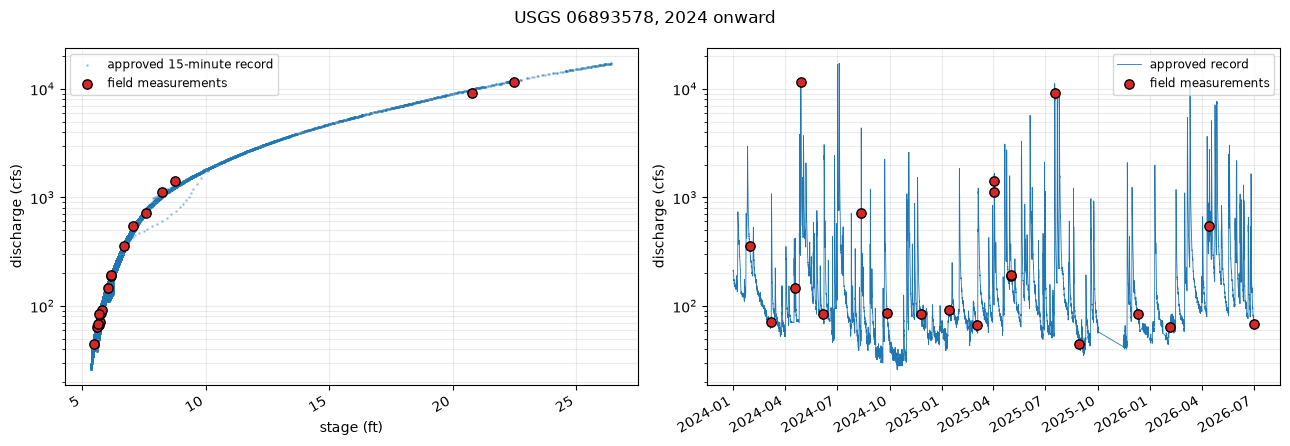

In [13]:
record = usgs.continuous_record(SITE, "2024-01-01", "2026-12-31")
record_local = record.assign(time=record["time"].dt.tz_localize(None))
print(f"{len(record_local):,} paired approved readings")

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))

left.scatter(record_local["stage_ft"], record_local["discharge_cfs"],
             s=1, alpha=0.3, color="tab:blue", label="approved 15-minute record")
left.scatter(recent_local["stage_ft"], recent_local["discharge_cfs"],
             s=45, color="tab:red", edgecolor="black", zorder=5,
             label="field measurements")
left.set_xlabel("stage (ft)")
left.set_ylabel("discharge (cfs)")
left.set_yscale("log")
left.grid(alpha=0.25, which="both")
left.legend(fontsize="small")

right.plot(record_local["time"], record_local["discharge_cfs"],
           lw=0.6, color="tab:blue", label="approved record")
right.scatter(recent_local["time"], recent_local["discharge_cfs"],
              s=45, color="tab:red", edgecolor="black", zorder=5,
              label="field measurements")
right.set_ylabel("discharge (cfs)")
right.set_yscale("log")
right.grid(alpha=0.25, which="both")
right.legend(fontsize="small")
fig.autofmt_xdate()
fig.suptitle(f"USGS {SITE}, 2024 onward")
plt.tight_layout()

### The sample

`gage_sample` applies the same date filter in one line and returns a `Sample`: stage on
the gage's own gage-height axis, so no datum conversion is needed and a fit is directly
comparable with the published rating.

`support()` distinguishes two very different causes of a poor score - the model is wrong,
or the measurements never constrained a rating in the first place. A handful of points
spanning less than a decade of discharge is the second case, and no curve is identifiable
from it however well the sampler behaves.

In [14]:
sample = lrc.gage_sample(SITE, start="2024-01-01")
print(sample)
print("stage     %.2f to %.2f ft" % sample.stage_range)
print("discharge %.3g to %.3g cfs" % sample.discharge_range)
print()
print("is a rating identifiable from these measurements?")
sample.support()

15:08:23 INFO    limnotech_rating_curves.data.usgs: USGS 06893578: 20 field measurement(s), stage 5.48-22.47 ft, discharge 45-1.16e+04 cfs


Sample(n=20, site='06893578')
stage     5.48 to 22.47 ft
discharge 45 to 1.16e+04 cfs

is a rating identifiable from these measurements?


{'n': 20,
 'distinct_discharge': 20,
 'discharge_min': 45.0,
 'discharge_max': 11600.0,
 'discharge_span_ratio': 257.77777777777777,
 'stage_range_ft': 16.99,
 'identifiable': True}

In [15]:
print(usgs.gage_datum(SITE))                   # ready to pass as stage_datum=

reference = usgs.published_reference(SITE, sample)
print()
print("the published rating, scored on these same measurements:")
print(reference["metrics"])

StageDatum(kind='constant', elevation_ft=718.41, series=None, name='NAVD88', label='USGS gage height (ft)', margin_fraction=0.1)

the published rating, scored on these same measurements:
{'rmse': 194.6201135417405, 'nse': 0.9959554003517193, 'pbias_pct': 3.1837095958434856, 'r2_log': 0.997537707026721, 'n': 20}


### Fitting the power law

The same call as section 1, on real measurements. `convergence_report` is the thing to
read before any score: a fit whose chains disagree has no posterior worth scoring.

c:\Users\dfarmer\AppData\Local\miniconda3\envs\rating_curves\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Output()

Output()

Output()

Metrics(n=20, nse=0.988, rmse=342, r2_log=0.996, elpd_loo=13.7)
converged: worst R-hat 1.0000 (threshold 1.01), lowest bulk ESS 596 (threshold 400)


Output()

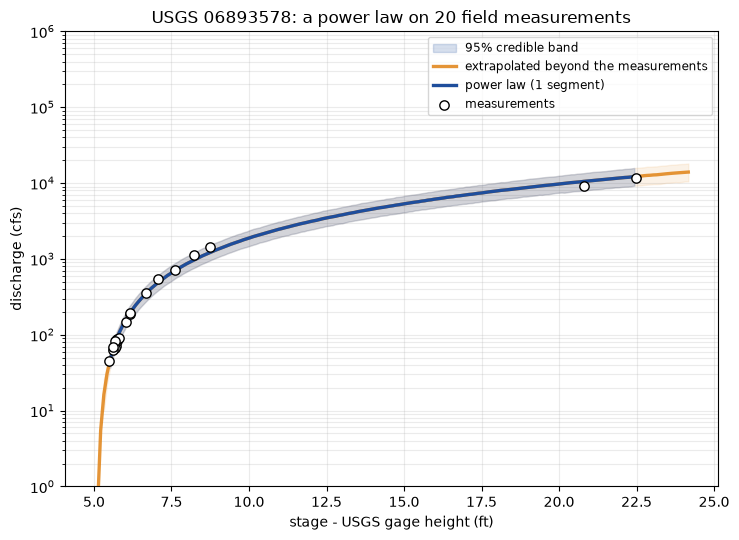

In [17]:
model = lrc.fit_rating(sample)                 # power law, full MCMC, seeded
print(model.metrics)
print(lrc.evaluate.diagnostics.convergence_report(model))

ax = model.plot()
ax.set_title(f"USGS {SITE}: a power law on {len(sample)} field measurements")
plt.tight_layout()

### The fit as an equation

The same three numbers as in section 1, now for a real station: the form to put in a
report, and the form somebody can check without rerunning anything. The full posterior is
`model.summary()`, which section 3 of `extras.ipynb` reads row by row.

In [18]:
print(model.equation())
print()
print("stage of zero flow:", round(model.zero_flow, 3), "ft")
model.coefficients

Q = 182.16 (h - 5.12323)^1.46971

stage of zero flow: 5.123 ft


{'coefficient': 182.16021140743,
 'exponents': array([1.46970612]),
 'breakpoints': array([5.12323216])}

<a id="compare"></a>
## 3. Comparing model families

| model | what it is | when to use it |
|---|---|---|
| `power_law` | $Q = C(h-e)^\beta$ | the default; the theoretical form of flow over a control, so it extrapolates upward defensibly |
| `power_law_2seg`, `power_law_3seg` | segmented power law | the control changes with stage, for example in-bank flow giving way to overbank |
| `spline` | natural cubic spline in log space | interpolation; flexible, and unconstrained above the highest measurement |
| `bdrc_gplm0` | bdrc generalized power law | the exponent varies smoothly with stage; priors tuned for short records |
| `bdrc_gplm`, `bdrc_plm0`, `bdrc_plm` | bdrc variants | stage-varying variance, and the plain power law under bdrc's priors |
| `quadratic`, `exponential` | least-squares forms | reproducing the curve a field spreadsheet drew, to compare against |

`compare` fits several models at once. A model that fails to fit does not stop the
others; its reason is recorded in `.failures`, and a sample too small for a model is
skipped with that reason rather than fitted badly.

Passing `reference=` puts the published USGS rating on the plot and in the metrics table,
scored on the same measurements. It has no predictive score, because it has no posterior.

In [21]:
comparison = lrc.compare(sample, reference=reference)     # the catalog's default keys
print(comparison)
print("failures:", comparison.failures)
comparison.metrics

c:\Users\dfarmer\AppData\Local\miniconda3\envs\rating_curves\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Output()

Output()

Output()

c:\Users\dfarmer\AppData\Local\miniconda3\envs\rating_curves\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


...

Output()

Output()

c:\Users\dfarmer\AppData\Local\miniconda3\envs\rating_curves\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


RatingSet(7 models on 06893578, n=20)
failures: {}


,model,label,n,nse,rmse,r2_log,elpd_loo,se_loo,p_loo,pareto_k_max
0,bdrc_gplm0,bdrc generalized power law (gplm0),20,0.999027,95.451941,0.998502,21.227526,3.035196,4.540772,0.797927
1,power_law_2seg,segmented power law (2 segments),20,0.996123,190.533528,0.998351,20.837418,2.686773,4.105500,0.845325
2,spline,natural spline,20,0.983300,395.464214,0.998002,15.153499,3.287828,7.215256,0.907325
3,power_law,power law (1 segment),20,0.987106,347.493767,0.996309,13.735803,2.401893,3.747917,0.724458
4,linear,refit - least-squares linear,20,0.988884,322.648202,0.959613,NaN,NaN,NaN,NaN
5,quadratic,refit - least-squares quadratic,20,0.997618,149.364084,0.983229,NaN,NaN,NaN,NaN
6,exponential,refit - log-linear exponential,20,0.596526,1943.828390,0.783670,NaN,NaN,NaN,NaN
7,published_reference,USGS published rating,20,0.995955,194.620114,0.997538,NaN,NaN,NaN,NaN


Output()

Output()

Output()

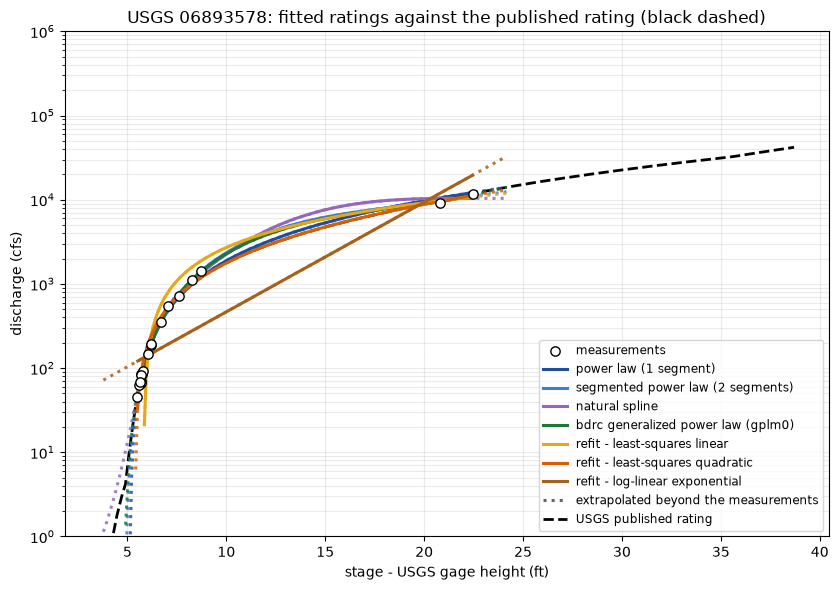

In [22]:
ax = comparison.plot()
ax.set_title(f"USGS {SITE}: fitted ratings against the published rating (black dashed)")
plt.tight_layout()

Which of these can be written down? `equation()` answers that in one table: the power
laws and the least-squares forms have a closed form, the spline and the bdrc models do
not - a spline is a basis matrix and its weights, and bdrc's exponent varies continuously
with stage. Those two are read through `curve()` and `predict()`.

In a segmented power law each later exponent is the *added* slope above its breakpoint,
not an absolute one. Near a breakpoint prefer `curve()` to the equation: the written
curve has one sharp kink at the mean breakpoint, while the posterior spreads its kink
over a range of stages and averages into a rounded one.

In [23]:
comparison.equation()

,model,label,equation
0,power_law,power law (1 segment),Q = 182.16 (h - 5.12323)^1.46971
1,power_law_2seg,segmented power law (2 segments),Q = 119.604 (h - 4.90147)^1.84511 (1 + max(h -...
2,spline,natural spline,
3,bdrc_gplm0,bdrc generalized power law (gplm0),
4,linear,refit - least-squares linear,Q = 648.423 h - 3775.78
5,quadratic,refit - least-squares quadratic,Q = 21.8788 h^2 + 47.7624 h - 894.446
6,exponential,refit - log-linear exponential,Q = 243.249 exp(0.300212 (h - 7.8355))


### Reading the metrics table

Two blocks, answering different questions.

**In-sample fit** - how close the curve passes to the measurements it was fitted to.

- `nse`, Nash-Sutcliffe efficiency. 1 is perfect; 0 is no better than predicting the mean
  observed discharge. It is computed in discharge units, so high flows dominate.
- `rmse`, root-mean-square error in cfs. Same caveat.
- `r2_log`, R-squared on log discharge. This is the one to read for a rating, because it
  weighs a factor-of-two error the same at 3 cfs as at 300 cfs, which is how rating error
  is judged in practice.

**Predictive score** - `elpd_loo`: how much probability density the model puts on a
measurement it has not seen. Higher is better. The in-sample scores all reward
flexibility, so a spline with enough knots fits the measurements at least as well as a
power law while saying nothing about the next measurement. `elpd_loo` is what addresses
that; `psis.ipynb` is where it comes from and when to distrust it.

In [24]:
for column, meaning in lrc.evaluate.metrics.METRIC_GLOSSARY.items():
    print(f"{column:<14} {meaning}")

curve          which rating this row scores - a fitted model, a least-squares spreadsheet form refitted here, or an external curve somebody else drew
n              measurements the model was fitted on
nse            Nash-Sutcliffe efficiency on discharge; 1 is perfect, 0 is no better than the mean observed discharge
rmse           root-mean-square error in cfs; in data units, so dominated by high flow
pbias_pct      percent bias; positive means the rating over-predicts on balance
r2_log         R-squared on log discharge - the one to read for a rating, because it weighs proportional error equally at all flows
elpd_loo       expected log predictive density for an unseen measurement, by PSIS-LOO. Higher is better; only differences on the same sample are meaningful
se_loo         standard error of elpd_loo; a gap under ~2 of these is not resolvable
p_loo          effective number of parameters implied by LOO; far above the model's real parameter count signals misfit or an over-influentia

### Choosing one

`ranking()` sorts the models by `elpd_loo` and puts each difference next to its standard
error. Two models within about two standard errors of each other are not distinguishable
by this sample, so take the simpler one.

In [25]:
comparison.ranking()

,model,label,elpd_loo,se_loo,elpd_diff,dse,p_loo,pareto_k_max,warning
0,bdrc_gplm0,bdrc generalized power law (gplm0),21.227526,3.035196,0.000000,0.000000,4.540772,0.797927,pareto_k > 0.7: LOO unreliable
1,power_law_2seg,segmented power law (2 segments),20.837418,2.686773,-0.390108,4.053537,4.105500,0.845325,pareto_k > 0.7: LOO unreliable
2,spline,natural spline,15.153499,3.287828,-6.074026,4.474621,7.215256,0.907325,pareto_k > 0.7: LOO unreliable
3,power_law,power law (1 segment),13.735803,2.401893,-7.491723,3.870595,3.747917,0.724458,pareto_k > 0.7: LOO unreliable
4,linear,refit - least-squares linear,NaN,NaN,NaN,NaN,NaN,NaN,
5,quadratic,refit - least-squares quadratic,NaN,NaN,NaN,NaN,NaN,NaN,
6,exponential,refit - log-linear exponential,NaN,NaN,NaN,NaN,NaN,NaN,


In [ ]:
best = comparison.best
print("best predictive score:", best.name)
print("R2log", round(best.metrics.r2_log, 4),
      "| elpd_loo", round(best.metrics.elpd_loo, 2))

<a id="exports"></a>
## 4. Saving a fit, reading it back, and moving it to another machine

Fitting is the expensive step, and it happens on the machine that has PyMC, ArviZ and a
working C toolchain. Everything downstream - the dashboard, the map, a colleague's
spreadsheet, a review three months later - reads a fit rather than producing one. The
export format is the boundary between the two.

A saved rating is two files that travel together:

| file | holds |
|---|---|
| `<site>__<model>.rating.json` | the manifest: what was fitted, how it was sampled, the measurements, the fitted curve as a table, the parameter summary, every score, worst R-hat, and a SHA-256 of the posterior |
| `<site>__<model>.nc` | the posterior draws, as ArviZ NetCDF |

The manifest is the half that can be read, diffed and opened with nothing but numpy and
pandas, so it carries the fitted curve as a table and a rating loaded from it predicts
immediately. The posterior is the half that cannot be reconstructed: every new score,
every different credible level and every re-plot on a new stage grid is computed from the
draws. It is written every time, and a save that could not write it raises rather than
succeeding partially.

File names use the catalog's own spelling of the model key, so a directory of exports is
keyed the same way `lrc.models.catalog.get` is. An older run's `PowerLawRating_1seg` is
written as `power_law`.

In [ ]:
from pathlib import Path

paths = lrc.save_rating(comparison.best, "fits", sample_id=SITE)

for half, path in paths.items():
    print(f"{half:<10} {Path(path).name:<40} {Path(path).stat().st_size / 1024:8.0f} KB")

14:24:45 INFO    limnotech_rating_curves.exports: wrote 06893578__bdrc_gplm0.rating.json


manifest   06893578__bdrc_gplm0.rating.json               46 KB
posterior  06893578__bdrc_gplm0.nc                      1960 KB


### What is in the manifest

Readable JSON, one level deep. The three long entries are what make a reloaded rating
useful on its own: the measurements it was fitted to, the fitted curve, and the parameter
summary.

In [ ]:
import json

manifest = json.loads(Path(paths["manifest"]).read_text(encoding="utf-8"))

for key, value in manifest.items():
    shape = f"{len(value)} rows" if isinstance(value, list) else ""
    print(f"{key:<18} {shape}")
print()
print("model  ", manifest["model"])
print("sampler", manifest["sampler"])        # every setting that changes the numbers
print("units  ", manifest["units"])

format             
format_version     
package_version    
written_utc        
site               
model              
sampler            
units              
measurements       20 rows
curve              189 rows
parameters         8 rows
metrics            
convergence        
native             
posterior_file     
posterior_sha256   

model   {'key': 'bdrc_gplm0', 'label': 'bdrc generalized power law (gplm0)', 'family': 'bdrc', 'equation': '', 'has_posterior': True}
sampler {'variant': 'gplm0', 'zero_flow_ft': None, 'method': 'nuts', 'nuts_sampler': 'nutpie', 'zero_flow_fitted_ft': 4.82097759701118}
units   {'stage': 'ft', 'discharge': 'cfs', 'stage_label': 'USGS gage height (ft)', 'datum_note': 'stage as read at the gage, above its own datum'}


### Reading it back

`load_rating` returns a `SavedRating`: the provenance, the curve, the scores, and the
draws on demand. `describe()` summarises the whole file, and it runs on a machine with
neither PyMC nor ArviZ installed, which is the purpose of the format.

In [ ]:
again = lrc.load_rating(paths["manifest"])
print(again.describe())

06893578__bdrc_gplm0.rating.json
  site         06893578   (usgs_gage, n=20)
  model        bdrc_gplm0  -  bdrc generalized power law (gplm0)   [bdrc]
  equation     (no closed form)
  stage range  4.908 to 24.17 ft   (189 curve points)
  stage axis   USGS gage height (ft)
  fitted by    nuts / nutpie   seed ?
  in-sample    NSE 0.999   RMSE 95.45 cfs   PBIAS 0.6%   R²log 0.999
  predictive   ELPD_LOO 21.2 ± 3.0   p_loo 4.5   worst Pareto-k 0.80
  convergence  worst R-hat 1.0000   lowest ESS 2102   converged
  posterior    06893578__bdrc_gplm0.nc   checksum verified
  written      2026-08-11T18:24:44+00:00  by limnotech_rating_curves 1.1.0  (format v2)


In [ ]:
print("same prediction as the live fit:",
      round(again.predict(12.0), 6), "vs", round(comparison.best.predict(12.0), 6))
print("stored 95% interval at 12 ft:", tuple(round(v, 3) for v in again.interval(12.0)))
print("stage range covered:", tuple(round(v, 2) for v in again.stage_range))
print()
print("scores, as recorded at fit time:", again.metrics)
print("convergence, as recorded:      ", again.convergence)
print()
again.parameters.head(4)

same prediction as the live fit: 3812.532478 vs 3812.532478
stored 95% interval at 12 ft: (2743.94, 5538.61)
stage range covered: (4.91, 24.17)

scores, as recorded at fit time: {'n': 20, 'nse': 0.9990270968097633, 'rmse': 95.45194129126243, 'pbias_pct': 0.6019037309134331, 'r2_log': 0.9985020650630455, 'elpd_loo': 21.227525606936357, 'se_loo': 3.035196230831758, 'p_loo': 4.540771502157284, 'elpd_waic': 21.743682272980905, 'pareto_k_max': 0.7979267172899202, 'elpd_loo_refits': 0, 'elpd_loo_psis': None}
convergence, as recorded:       {'available': True, 'worst_r_hat': 1.0, 'lowest_ess_bulk': 2102.0, 'converged': True, 'note': '', 'r_hat_threshold': 1.01, 'ess_threshold': 400}



,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,theta[0],-1.623,0.189,-1.989,-1.277,0.004,0.004,2515.0,1675.0,1.0
1,theta[1],-5.310,0.355,-5.965,-4.649,0.007,0.007,2794.0,2168.0,1.0
2,theta[2],-1.128,0.397,-1.885,-0.401,0.008,0.006,2842.0,2344.0,1.0
3,theta[3],1.052,0.732,-0.314,2.434,0.017,0.020,2102.0,1588.0,1.0


<Axes: title={'center': '06893578: a saved rating interpolates its stored curve'}, xlabel='stage (ft)', ylabel='discharge (cfs)'>

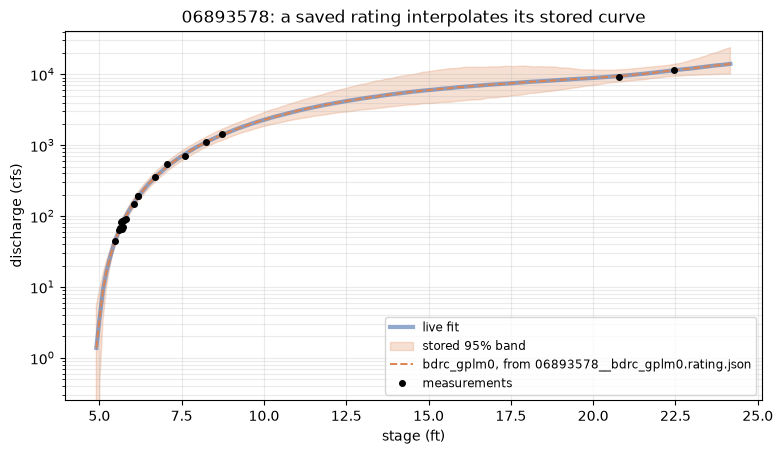

In [ ]:
# The reloaded rating against the live one. They lie on top of each other inside the
# stored range and the reloaded one simply stops at its ends, which is the whole
# difference between a SavedRating and a live fit.
again.plot(live=comparison.best)

### What a `SavedRating` is not

It is not a `RatingModel`. It cannot be refitted, and it does not rebuild the model
object. A `ratingcurve` posterior can be reloaded into a live model by that package, but
a bdrc fit cannot, because its curve comes from a closed-form kriging step that is not
stored. Rather than round-trip one family and approximate the other, neither is rebuilt:
a saved rating predicts by interpolating the stored curve, which is what the map and the
dashboard do with a live fit anyway.

Two consequences:

- `predict` outside the stored curve's range returns NaN rather than extrapolating.
- `interval` at a different credible level raises. The band was written at the level the
  fit reported; a different level requires the draws, which is what `posterior()` is for.

In [ ]:
low, high = again.stage_range
print("Q above the stored curve:", again.predict(high + 1.0), "(NaN, not extrapolated)")

try:
    again.interval(5.0, level=0.90)
except ValueError as exc:
    print()
    print("refused:", exc)

Q above the stored curve: nan (NaN, not extrapolated)

refused: a saved rating stores one credible band, so it cannot be re-evaluated at a different level; load posterior() and compute it from the draws instead


In [ ]:
idata = again.posterior()           # read on demand, not at load time
print("reloaded posterior groups:", list(idata.groups()))

# a band at any credible level is computed from these draws
print("parameters in the file:", list(idata.posterior.data_vars))
print("draws:", dict(idata.posterior.sizes))

reloaded posterior groups: ['posterior', 'log_likelihood', 'sample_stats', 'warmup_posterior', 'warmup_sample_stats']
parameters in the file: ['theta', 'zeta', 'log_sigma_eps2', 'log_sigma_beta', 'log_phi_beta']
draws: {'chain': 4, 'draw': 1000, 'theta_dim_0': 4}


### Integrity

A manifest that arrives without its posterior, or with a truncated one, still reads
perfectly, because every number in the manifest is intact. The SHA-256 recorded at write
time is therefore checked rather than assumed. `verify()` performs that check, and
`posterior()` runs it before returning draws.

In [ ]:
import shutil

print("intact pair:", again.verify())

# copy only the manifest, as an interrupted transfer would
half = Path("half_a_copy")
half.mkdir(exist_ok=True)
shutil.copy2(paths["manifest"], half / Path(paths["manifest"]).name)

split = lrc.load_rating(half / Path(paths["manifest"]).name)
print()
print("split pair: ", split.verify())
try:
    split.posterior()
except FileNotFoundError as exc:
    print()
    print("raised:", exc)

intact pair: {'ok': True, 'posterior_present': True, 'checksum_recorded': True, 'checksum_matches': True, 'problem': ''}

split pair:  {'ok': False, 'posterior_present': False, 'checksum_recorded': True, 'checksum_matches': None, 'problem': 'the posterior 06893578__bdrc_gplm0.nc is not next to 06893578__bdrc_gplm0.rating.json; the pair has been split'}

raised: the posterior 06893578__bdrc_gplm0.nc is not next to 06893578__bdrc_gplm0.rating.json; the two files travel together and one has been moved or deleted. Copy both, or refit.


### Models with no posterior

The least-squares forms, `quadratic` and `exponential`, have no draws, so a missing `.nc`
beside them is expected rather than a loss. `expects_posterior` distinguishes the two
cases, and `verify()` uses it so that a quadratic export is not reported as broken.

These are also the models whose reloaded `predict` is exact rather than interpolated: the
manifest carries the closed form, so the coefficients are evaluated the way the live fit
evaluates them.

In [ ]:
# The same measurements fitted the way a spreadsheet would fit them: least squares, no
# posterior. Its manifest carries the coefficients, so a reloaded quadratic predicts
# exactly rather than by interpolation.
gage_quadratic = lrc.fit_rating(sample, model="quadratic")
print(gage_quadratic.equation())

quadratic_paths = lrc.save_rating(gage_quadratic, "fits", sample_id=SITE)
print("posterior written:", quadratic_paths["posterior"])

saved_quadratic = lrc.load_rating(quadratic_paths["manifest"])
print("expects_posterior:", saved_quadratic.expects_posterior)
print("verify:           ", saved_quadratic.verify())
print()
print("exact, not interpolated:", saved_quadratic.predict(12.0),
      "vs", gage_quadratic.predict(12.0))

14:24:45 INFO    limnotech_rating_curves.evaluate.diagnostics: this fit kept no posterior, so there is nothing to summarize


14:24:45 INFO    limnotech_rating_curves.evaluate.diagnostics: this fit kept no posterior, so there is nothing to summarize


14:24:45 INFO    limnotech_rating_curves.exports: wrote 06893578__quadratic.rating.json (no posterior)


Q = 21.8788 h^2 + 47.7624 h - 894.446
posterior written: None
expects_posterior: False
verify:            {'ok': True, 'posterior_present': False, 'checksum_recorded': False, 'checksum_matches': None, 'problem': ''}

exact, not interpolated: 2829.2488866281733 vs 2829.2488866281733


### A whole directory at once

`load_ratings` reads every manifest in a directory into `{(site, model): SavedRating}`. A
batch run writes these into `<output_dir>/fitted_curves`, so this is how a previous run is
reconstructed without refitting anything.

Two tables summarise that dict: `manifest_index` gives one row per rating (identity,
scores, stage range, and whether the pair is intact), and `curve_table` stacks every
fitted curve into one long frame, which is the one to open in Excel.

In [ ]:
loaded = lrc.load_ratings("fits")
print(len(loaded), "rating(s):", list(loaded))

lrc.manifest_index(loaded)

4 rating(s): [('06893578', 'bdrc_gplm0'), ('06893578', 'quadratic'), ('SBR-09_elev', 'quadratic'), ('SBR-09_pagaia', 'power_law')]


,site,model,model_label,family,n,method,stage_low_ft,stage_high_ft,equation,nse,rmse,r2_log,elpd_loo,se_loo,pareto_k_max,worst_r_hat,manifest_file,posterior_file,intact,problem
0,06893578,bdrc_gplm0,bdrc generalized power law (gplm0),bdrc,20,nuts,4.907975,24.169,,0.999027,95.451941,0.998502,21.227526,3.035196,0.797927,1.0,06893578__bdrc_gplm0.rating.json,06893578__bdrc_gplm0.nc,True,
1,06893578,quadratic,refit - least-squares quadratic,polynomial,20,least_squares,5.480000,22.470,Q = 21.8788 h^2 + 47.7624 h - 894.446,0.997618,149.364084,0.983229,NaN,NaN,NaN,NaN,06893578__quadratic.rating.json,NaN,True,
2,SBR-09_elev,quadratic,refit - least-squares quadratic,polynomial,7,least_squares,797.550000,800.840,Q = 4.47598 h^2 - 7133.39 h + 2.84213e+06,0.998204,0.993567,0.927702,NaN,NaN,NaN,NaN,SBR-09_elev__quadratic.rating.json,NaN,True,
3,SBR-09_pagaia,power_law,power law (1 segment),ratingcurve,5,nuts,0.600000,3.690,,0.899552,8.339875,0.974991,-4.548949,1.757692,0.976052,1.0,SBR-09_pagaia__power_law.rating.json,SBR-09_pagaia__power_law.nc,True,


In [ ]:
lrc.curve_table(loaded).head(4)

,site,model,model_label,family,equation,stage_ft,discharge_cfs,discharge_median_cfs,lower,upper,nse,rmse,r2_log
0,06893578,bdrc_gplm0,bdrc generalized power law (gplm0),bdrc,,4.907975,1.379420,1.379420,0.000000,5.399764,0.999027,95.451941,0.998502
1,06893578,bdrc_gplm0,bdrc generalized power law (gplm0),bdrc,,5.010427,3.744739,3.744739,0.431074,9.258825,0.999027,95.451941,0.998502
2,06893578,bdrc_gplm0,bdrc generalized power law (gplm0),bdrc,,5.112879,9.173327,9.173327,3.439244,15.401751,0.999027,95.451941,0.998502
3,06893578,bdrc_gplm0,bdrc generalized power law (gplm0),bdrc,,5.215332,16.451139,16.451139,9.736327,23.209644,0.999027,95.451941,0.998502


A `.nc` file on its own is not a saved rating: it holds draws over parameter names and
nothing that identifies the site, the stage axis, or the curve. `load_ratings` reports
that rather than returning an empty dict silently, and `orphan_posteriors` lists what a
run could not use.

In [ ]:
orphans_only = Path("orphans_only")
orphans_only.mkdir(exist_ok=True)
shutil.copy2(paths["posterior"], orphans_only / Path(paths["posterior"]).name)

print("load_ratings ->", lrc.load_ratings(orphans_only))
print("orphans      ->", [path.name for path in
                          lrc.exports.orphan_posteriors(orphans_only)])

14:24:45 WARNING limnotech_rating_curves.exports: orphans_only holds 2 posterior file(s) and no manifest, so none of them can be loaded: a posterior on its own records neither the site nor the curve. Refit, or export from a run that writes both halves.


load_ratings -> {}
orphans      -> ['06893578__bdrc_gplm0.nc', 'SBR-09_pagaia__power_law.nc']


### A portable copy for another machine

`export_directory` collects a directory of pairs into a portable set: the
manifest/posterior pairs plus two tables written for people rather than programs,
`ratings_index.csv` and `rating_curves.csv`. Nothing else in this repository has to
travel with it.

The return value names what could not travel: `orphans` (posteriors with no manifest) and
`problems` (pairs whose checksum or posterior did not check out).

In [ ]:
outcome = lrc.export_directory("fits", "ship")

print("ratings exported:", outcome["ratings"])
print("orphans left behind:", outcome["orphans"])
print("integrity problems:", outcome["problems"])
print()
for path in outcome["files"]:
    print(" ", Path(path).name)

14:24:45 INFO    limnotech_rating_curves.exports: exported 4 rating(s) to ship


ratings exported: 4
orphans left behind: []
integrity problems: []

  06893578__bdrc_gplm0.rating.json
  06893578__bdrc_gplm0.nc
  06893578__quadratic.rating.json
  SBR-09_elev__quadratic.rating.json
  SBR-09_pagaia__power_law.rating.json
  SBR-09_pagaia__power_law.nc
  ratings_index.csv
  rating_curves.csv


### A whole sweep, rebuilt from its files

Because `fit_many` writes as it goes, a directory of exports is a run.
`RatingCollection.from_directory` returns an object of the same shape as the one the
sweep returned, so analysis code cannot tell the difference.

In [ ]:
reloaded = lrc.RatingCollection.from_directory("fits")
print(reloaded)
reloaded.metrics[["site", "model", "n", "nse", "r2_log", "elpd_loo"]]

RatingCollection(4 ratings over 3 site(s), dir='fits')


,site,model,n,nse,r2_log,elpd_loo
0,06893578,bdrc_gplm0,20,0.999027,0.998502,21.227526
1,06893578,quadratic,20,0.997618,0.983229,NaN
2,SBR-09_elev,quadratic,7,0.998204,0.927702,NaN
3,SBR-09_pagaia,power_law,5,0.899552,0.974991,-4.548949


## Where to go next

The shortest path from a CSV of stage and discharge pairs to a defensible rating:

1. Get stage onto gage height. Pass `stage_datum=` an `alt_va` if the site is surveyed,
   or `"lowest"` if it is not, and read back `sample.datum_note` to confirm what was
   subtracted (`extras.ipynb`, section 1).
2. Check that a rating is identifiable at all, with `sample.support()`, before reading
   any score (section 2).
3. Fit several families with `lrc.compare(...)`, then check convergence before the
   metrics table (section 3, and `extras.ipynb` section 3).
4. Choose on `ranking()` rather than on `r2_log`, and treat two models within about two
   standard errors as indistinguishable (section 3, and `psis.ipynb`).
5. Confirm the choice with `cross_validate`, and with `high_flow_skill` if the high end
   matters, which it usually does (`extras.ipynb`, section 4).
6. Read the chosen fit back as an equation with `equation()`, so it can be quoted,
   reviewed and typed into a spreadsheet (sections 1 to 3).
7. Save with `save_rating` so the fit can be read later without refitting (section 4).